# 92 Grid services

Curtailment charge, discharge to load, ramping, Q support.


## Governing equations

Default electrolyte $6\,\mathrm{M}$ KOH at $303\,\mathrm{K}$ unless noted.
Quantities use Jupyter MathJax with $\mathrm{}$ SI (siunitx is not available).
Patents: US12308414B2, EP4602674A1.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

here = Path.cwd()
for cand in (here, here.parent):
    if (cand / "src" / "ironair").is_dir() and (cand / "plant_sim").is_dir():
        sys.path.insert(0, str(cand))
        sys.path.insert(0, str(cand / "src"))
        break

from plant_sim.bootstrap import setup_path

setup_path()
from plant_sim.params import CAPACITY_FE_OH2_MAH_G, CAPACITY_MAGNETITE_MAH_G, default_params

In [2]:
from IPython import get_ipython

_ipy = get_ipython()
if _ipy is not None:
    _ipy.run_line_magic("matplotlib", "inline")

sns.set(
    rc={
        "axes.labelsize": 12,
        "axes.titlesize": 18,
        "figure.figsize": (11, 8.5),
        "figure.dpi": 300,
        "figure.facecolor": "w",
        "figure.edgecolor": "k",
    }
)
P = default_params()
print("KOH default", P.c_KOH_mol_m3 / 1000, "M; T_ep", P.T_ep_sim_K, "K")
print("Faraday 960/320 checks", round(CAPACITY_FE_OH2_MAH_G, 2), round(CAPACITY_MAGNETITE_MAH_G, 2))

KOH default 6.0 M; T_ep 303.15 K
Faraday 960/320 checks 959.85 319.95


## Simulation setup

Integrate the model once. Plot sections below each document what is shown, why it matters for patent/requirement verification, and the equations that govern that view.


In [3]:
from plant_sim.plant import PlantModel
from plant_sim.scenarios.mission import grid_services_inputs

plant = PlantModel(P)
r = plant.simulate((0, 3600), inputs=grid_services_inputs(P), n_eval=180, rtol=1e-4)

## Grid services: curtailment, load, ramp

### What this plot illustrates

Plant following a grid-services power schedule: charge on curtailment, discharge to load, and ramps (IA-GRD-001).

### Governing equations

$P_\mathrm{cmd}(t)$ piecewise; $I_\mathrm{cell}=P_\mathrm{cmd}/V_\mathrm{cell}$ with mode charge if $P>0$ into battery.


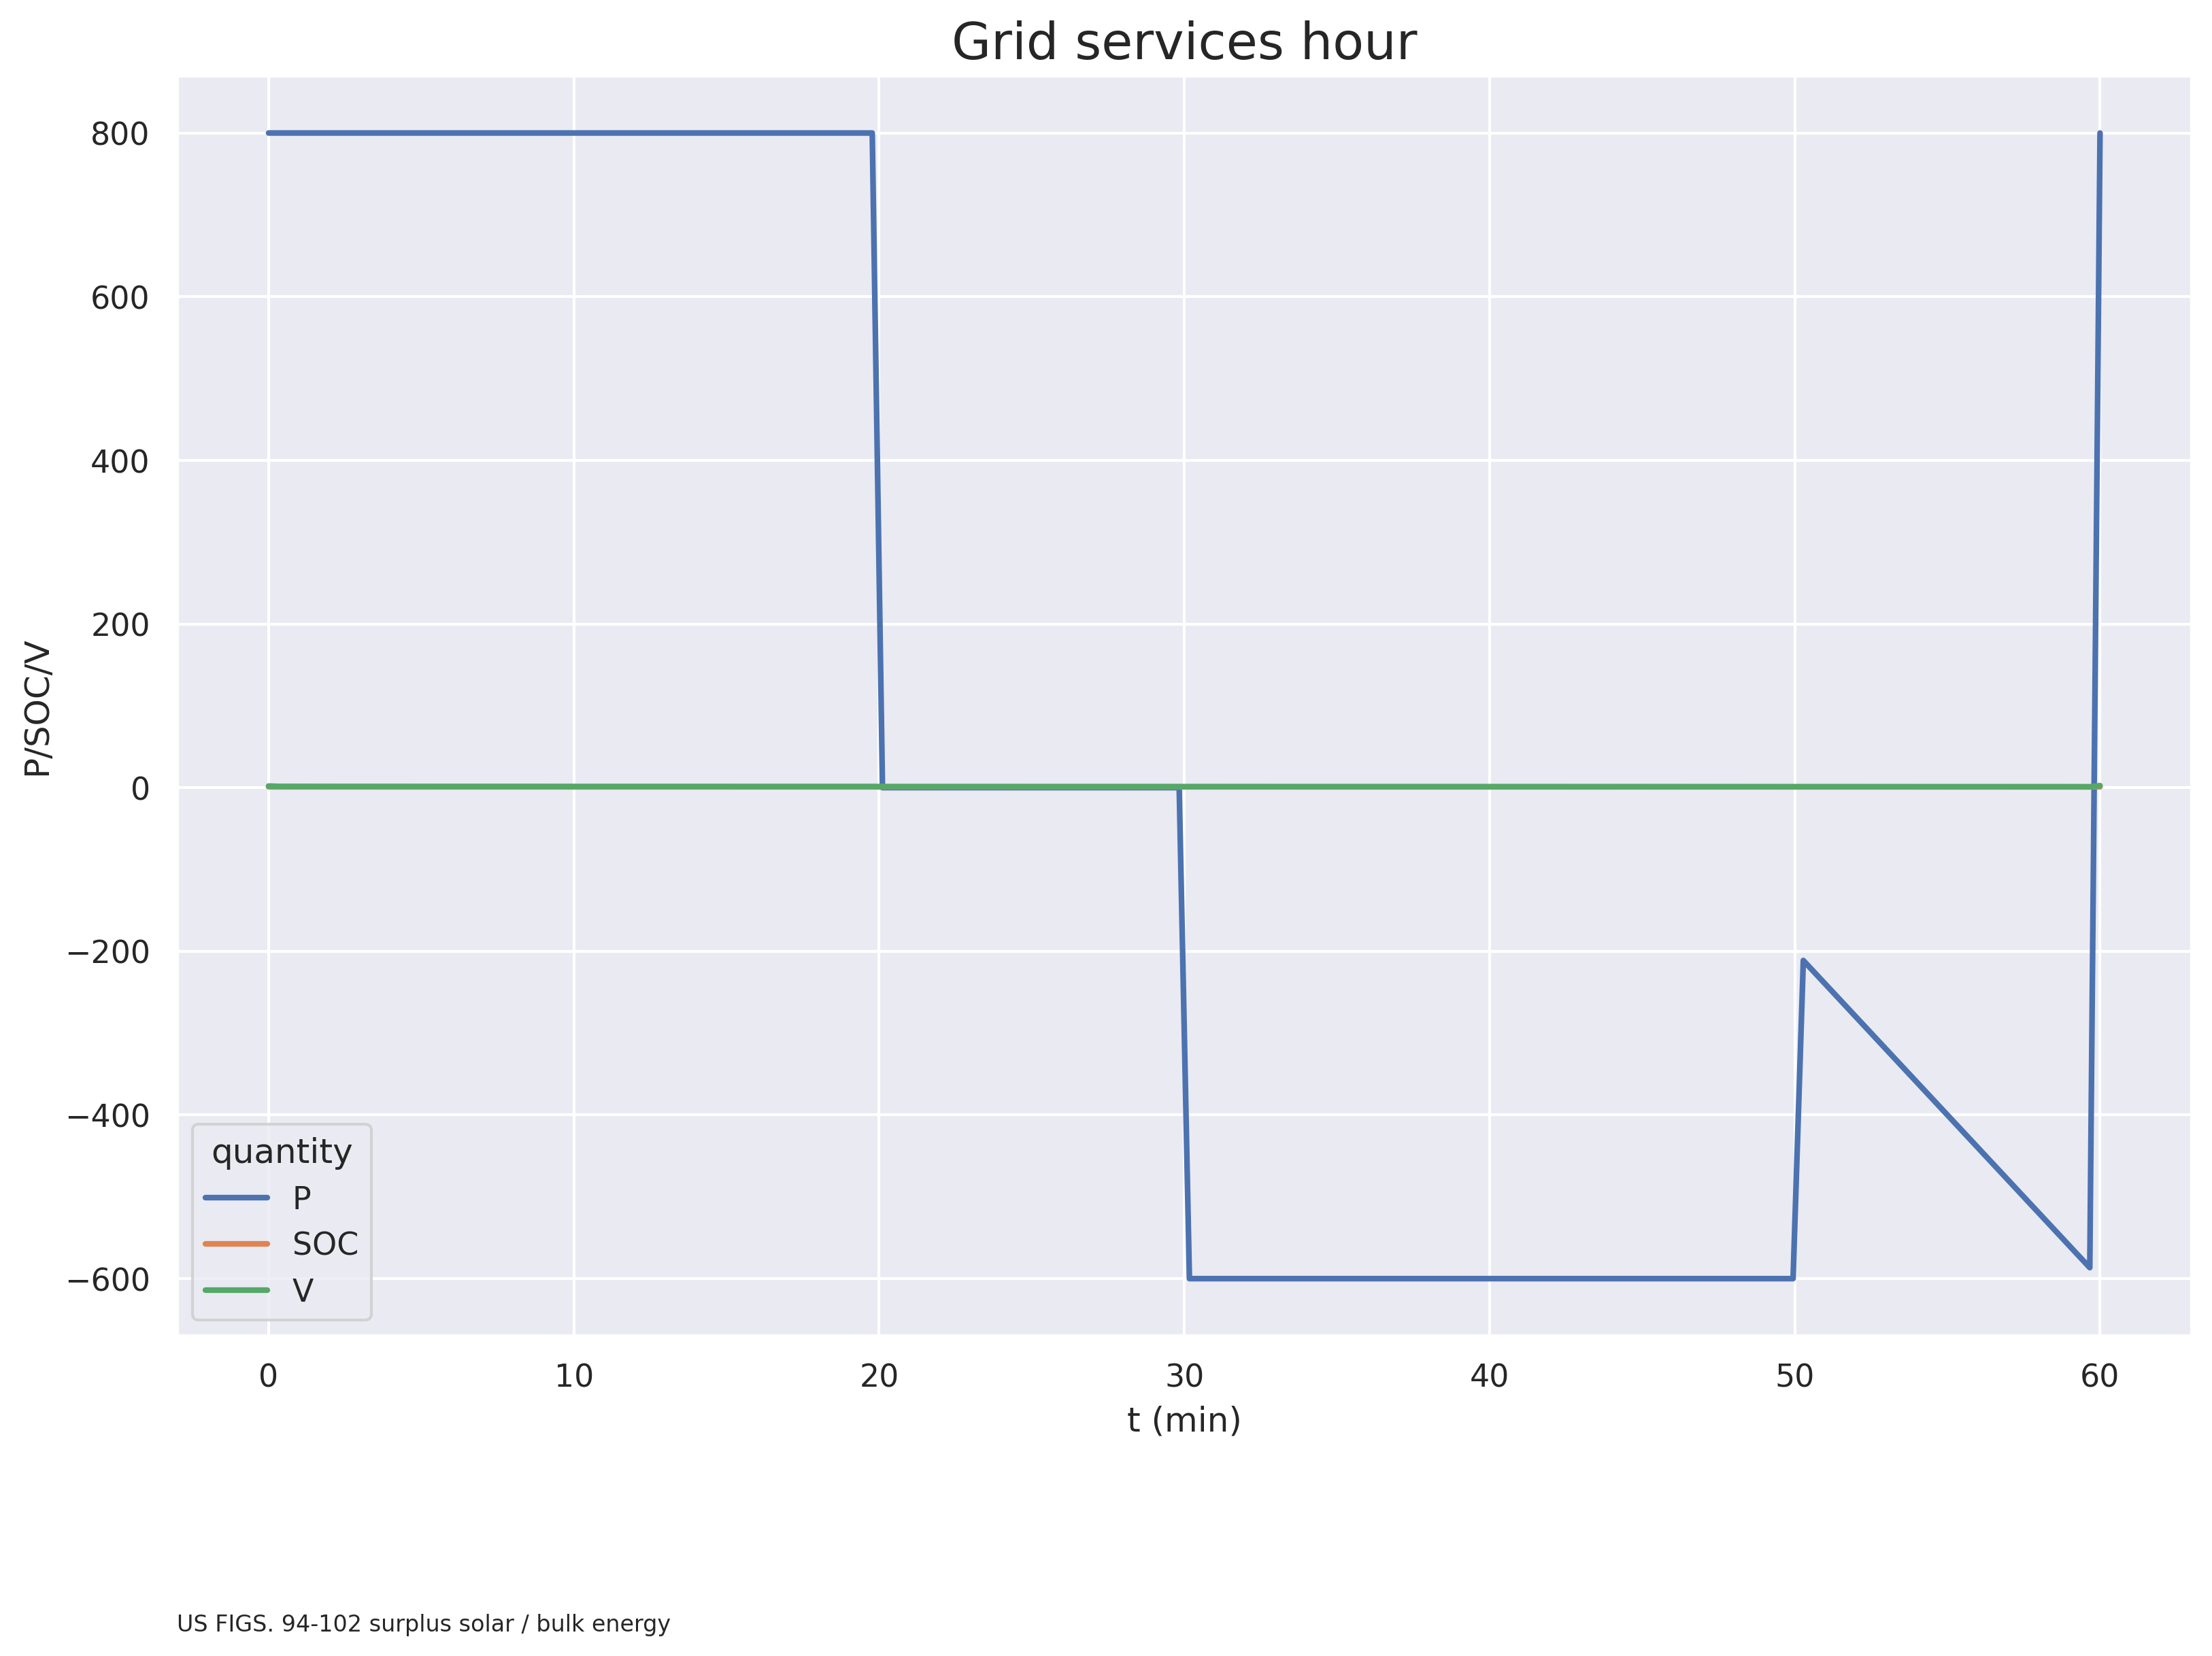

In [4]:
plot_frame = pd.DataFrame(
    {
        "t": (r["t"] / 60),
        "P": (r["alg"]["P_grid_W"]),
        "SOC": (r["alg"]["SOC"]),
        "V": (r["alg"]["V_cell_V"]),
    }
)
plot_long = plot_frame.melt(id_vars="t", var_name="quantity", value_name="value")
fig, ax = plt.subplots()
sns.lineplot(data=plot_long, x="t", y="value", hue="quantity", ax=ax, linewidth=2.0)
ax.set_xlabel("t (min)")
ax.set_ylabel("P/SOC/V")
ax.set_title("Grid services hour")
ax.text(0.0, -0.22, "US FIGS. 94-102 surplus solar / bulk energy", transform=ax.transAxes, fontsize=8, va="top")
fig.tight_layout()
fig.subplots_adjust(bottom=0.22)

## Verification against patents / SSS002

In [5]:
print("finite trajectories and patent-window parameters: see printed checks above")

finite trajectories and patent-window parameters: see printed checks above
